We need to understand why we are choosing Random Forest when I am havinfg Decision Tree
Decision Tree is having one big problem -> Over fitting

To overcome this issue we are using Random forest
In the random Forest we are going to have multiple trees.
These trees data been selected random from the orginal data.
That menas each tree is having different data.
All these trees are going to work simultaneously and provide pridiction.
Random forest collects all the trees outputs and now this random forest takes decision

## Overview of Random Forest Algorithm

The Decision Tree is an easily understood and interpreted algorithm and hence a single tree may not be enough for the model to learn the features from it. On the other hand, Random Forest is also a “Tree”-based algorithm that uses the qualities features of multiple Decision Trees for making decisions.

Therefore, it can be referred to as a ‘Forest’ of trees and hence the name “Random Forest”. The term ‘Random’ is due to the fact that this algorithm is a forest of ‘Randomly created Decision Trees’.

The Decision Tree algorithm has a major disadvantage in that it causes over-fitting. This problem can be limited by implementing the Random Forest Regression in place of the Decision Tree Regression. Additionally, the Random Forest algorithm is also very fast and robust than other regression models.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [26]:
dataset = pd.read_csv('IceCreamData.csv')

In [27]:
dataset.head(5)

,Temperature,Revenue
0,24.566884,534.799028
1,26.005191,625.190122
2,27.790554,660.632289
3,20.595335,487.706960
4,11.503498,316.240194


In [28]:
X = dataset['Temperature'].values
y = dataset['Revenue'].values

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.05)

In [30]:
from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor()
rf_regressor.fit(X_train.reshape(-1,1), y_train.reshape(-1,1))

C:\Users\gn221m\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until


RandomForestRegressor()

In [10]:
y_pred = rf_regressor.predict(X_test.reshape(-1,1))
y_pred

array([237.26249911, 813.18111482, 555.15776424, 646.21231985,
       598.98844621, 455.02959589, 552.53985846, 270.77789954,
       497.66344077, 588.59872534, 670.05771667, 430.57044703,
       415.20275235, 397.12710363, 415.00788505, 550.73240572,
       950.17828776, 689.17695914, 288.3419094 , 342.61956923,
       813.18111482, 552.53985846, 653.9867356 , 632.89174131,
       427.08932025])

In [11]:
df = pd.DataFrame({'Real Values':y_test.reshape(-1), 'Predicted Values':y_pred.reshape(-1)})
df

,Real Values,Predicted Values
0,258.286810,237.262499
1,800.202494,813.181115
2,584.399945,555.157764
3,660.632289,646.212320
4,596.236690,598.988446
5,476.794525,455.029596
6,523.124547,552.539858
7,235.364643,270.777900
8,478.598509,497.663441
9,603.091382,588.598725


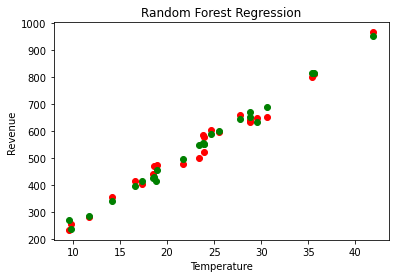

In [12]:
X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X_test, y_test, color = 'red')
plt.scatter(X_test, y_pred, color = 'green')
plt.title('Random Forest Regression')
plt.xlabel('Temperature')
plt.ylabel('Revenue')
plt.show()

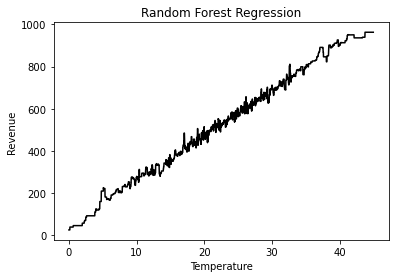

In [13]:
plt.plot(X_grid, rf_regressor.predict(X_grid), color = 'black')
plt.title('Random Forest Regression')
plt.xlabel('Temperature')
plt.ylabel('Revenue')
plt.show()

In [20]:
from sklearn import metrics
from sklearn.metrics import mean_squared_error
from math import sqrt
meanAbErr = metrics.mean_absolute_error(y_test, y_pred)
meanSqErr = metrics.mean_squared_error(y_test, y_pred)
rootMeanSqErr = sqrt(mean_squared_error(y_test,y_pred))

print('Mean Absolute Error:', meanAbErr)
print('Mean Square Error:', meanSqErr)
print('Root Mean Square Error:', rootMeanSqErr)

Mean Absolute Error: 22.155845062000015
Mean Square Error: 660.5673286456554
Root Mean Square Error: 25.701504404327295


Tunning the random forest parameters we can increase the accuracy

1) n_estimators 

2) max_depth

Find the accuracy

### Hyper Parameter tuning the Random Forest Algorithm

In [22]:
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 10, stop = 100, num = 10)]
# Number of features to consider at every split
max_features = ['auto']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2,4,6]
# Minimum number of samples required at each leaf node
min_samples_leaf = [2,4,6]
# Method of selecting samples for training each tree
bootstrap = [True, False]
criterion = ['mse','mae']
# Create the parameters grid

param_grid = {'n_estimators': n_estimators,
              'criterion': criterion,
              'max_features': max_features,
              'max_depth': max_depth,
              'min_samples_split': min_samples_split,
              'min_samples_leaf': min_samples_leaf,
              'bootstrap': bootstrap}
print(param_grid)

{'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'criterion': ['mse', 'mae'], 'max_features': ['auto'], 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, None], 'min_samples_split': [2, 4, 6], 'min_samples_leaf': [2, 4, 6], 'bootstrap': [True, False]}


In [39]:
from sklearn.model_selection import GridSearchCV
# Create a based model
rf = RandomForestRegressor()
# Instantiate the grid search model
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, 
                          cv = 5, n_jobs = -1, verbose = 2)

In [40]:
# Fit the grid search to the data
grid_search.fit(X_train.reshape(-1,1), y_train.reshape(-1,1))

# Fitting 3 folds for each of 4320 candidates, totalling 12960 fits   -- when we used cv=3

# Fitting 5 folds for each of 4320 candidates, totalling 21600 fits -- when we used CV=5

Fitting 5 folds for each of 4320 candidates, totalling 21600 fits


C:\Users\gn221m\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:926: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.best_estimator_.fit(X, y, **fit_params)
C:\Users\gn221m\Anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:407: FutureWarning: Criterion 'mae' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='absolute_error'` which is equivalent.
  FutureWarning,


GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'criterion': ['mse', 'mae'],
                         'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100,
                                       110, None],
                         'max_features': ['auto'],
                         'min_samples_leaf': [2, 4, 6],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100]},
             verbose=2)

In [32]:
grid_search.best_params_

'''
{'bootstrap': True,
 'criterion': 'mae',
 'max_depth': 10,
 'max_features': 'auto',     ----- when we use cv=3
 'min_samples_leaf': 2,
 'min_samples_split': 6,
 'n_estimators': 100}
'''




{'bootstrap': True,
 'criterion': 'mae',
 'max_depth': 10,
 'max_features': 'auto',
 'min_samples_leaf': 2,
 'min_samples_split': 6,
 'n_estimators': 100}

In [35]:
rf_tuned = RandomForestRegressor(n_estimators=100,criterion='mse',max_features='auto', max_depth=10,
                                 min_samples_split=6,min_samples_leaf=2,bootstrap=True,n_jobs=-1)
rf_tuned.fit(X_train.reshape(-1,1), y_train.reshape(-1,1))

C:\Users\gn221m\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until
C:\Users\gn221m\Anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:400: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  FutureWarning,


RandomForestRegressor(criterion='mse', max_depth=10, min_samples_leaf=2,
                      min_samples_split=6, n_jobs=-1)

In [36]:
y_pred_tuned = rf_tuned.predict(X_test.reshape(-1,1))
y_pred_tuned

array([688.02306609, 477.3021814 , 683.93280942, 462.98413985,
       529.77623769, 474.00493933, 763.62825006, 602.79388275,
       628.63894459, 291.48821355, 427.19027355, 258.44180267,
       603.40079337, 540.69029174, 626.21501333, 321.5441784 ,
       662.25478038, 293.13526477, 671.05485459, 262.7722115 ,
       473.91902165, 567.59829525, 262.37768151, 508.20518689,
       601.60138591])

In [37]:
df_tuned = pd.DataFrame({'Real Values':y_test.reshape(-1), 'Predicted Values':y_pred_tuned.reshape(-1)})
df_tuned

,Real Values,Predicted Values
0,642.227291,688.023066
1,475.538209,477.302181
2,654.747461,683.932809
3,451.450784,462.984140
4,512.588107,529.776238
5,456.524341,474.004939
6,756.037702,763.628250
7,627.901841,602.793883
8,594.651009,628.638945
9,279.866148,291.488214


In [38]:
meanAbErr = metrics.mean_absolute_error(y_test, y_pred_tuned)
meanSqErr = metrics.mean_squared_error(y_test, y_pred_tuned)
rootMeanSqErr = sqrt(mean_squared_error(y_test,y_pred_tuned))

print('Mean Absolute Error:', meanAbErr)
print('Mean Square Error:', meanSqErr)
print('Root Mean Square Error:', rootMeanSqErr)

Mean Absolute Error: 18.999895782311455
Mean Square Error: 549.4989397480597
Root Mean Square Error: 23.441393724522005
